In [1]:
import pandas as pd
import regex as re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_recall_fscore_support
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import LabelEncoder
from collections import Counter
from imblearn.over_sampling import SMOTE, RandomOverSampler
from xgboost import XGBClassifier
import matplotlib.font_manager as fm
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
file_path = r"C:\Users\sai namitha\Documents\youtube_comments_dataset_labeled1.csv"
df = pd.read_csv(file_path)

In [3]:
df.head(5)

,Column1,Column2,channel_title,username,comment_text,emotion
0,xqdXSA8hNI4,"KINGDOM Official Trailer | Vijay Deverakonda, ...",Sithara Entertainments,@MENDENARESH-es4sx,వర్రెస్ట్ తూ,anger
1,xqdXSA8hNI4,"KINGDOM Official Trailer | Vijay Deverakonda, ...",Sithara Entertainments,@bharathdraxchannel,మన కోల్పోయిన కుటుంబాన్ని అపవాదు చేసే మీ చిత్రా...,neutral
2,xqdXSA8hNI4,"KINGDOM Official Trailer | Vijay Deverakonda, ...",Sithara Entertainments,@sureshmarimuthu2580,ఈ సినిమా చాలా చెత్తగా ఉంది.😂😂😂😂,anger
3,xqdXSA8hNI4,"KINGDOM Official Trailer | Vijay Deverakonda, ...",Sithara Entertainments,@prahaladanature,ఇది zandubomb సినిమా చూడవలసిన అవసరము లేదు,anger
4,xqdXSA8hNI4,"KINGDOM Official Trailer | Vijay Deverakonda, ...",Sithara Entertainments,@SrinivasKorne,ఎవడ్రా ఈ స్టోరీ రాసింది ✍️ వాళ్ళ అన్న కోసం అన్...,neutral


In [4]:
df.describe()

,Column1,Column2,channel_title,username,comment_text,emotion
count,1100,1100,1100,1100,1100,1100
unique,69,68,52,979,1076,6
top,KgBG8CmgkpQ,లోకేష్ నీచ రాజకీయాలు #lakshmiparvathi #naralok...,ETV Jabardasth,@AshokBabu-k7b,సూపర్,neutral
freq,71,71,189,8,7,773


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Column1        1100 non-null   object
 1   Column2        1100 non-null   object
 2   channel_title  1100 non-null   object
 3   username       1100 non-null   object
 4   comment_text   1100 non-null   object
 5   emotion        1100 non-null   object
dtypes: object(6)
memory usage: 51.7+ KB


In [6]:
# Text Cleaning + Tokenization

telugu_stopwords = ["అది", "ఇది", "కాని", "లేక", "కూడా", "మాత్రం", "ఉంది", "చాలా", "వంటి", "ఎక్కువ", "తక్కువ"]

def tokenize_and_clean_sample(text, print_debug=False):
    if print_debug:
        print("\nOriginal:", text)
    
    text = re.sub(r'@\w+', '', text)   # remove mentions
    text = re.sub(r'[\u200B-\u200D\uFEFF]', '', text)   # remove zero-width chars
    text = re.sub(r'[^\u0C00-\u0C7F\s]', '', text)  # keep only Telugu
    text = re.sub(r'(.)\1{2,}', r'\1', text)        # reduce letter repetitions
    text = text.strip()
    
    tokens = text.split()
    tokens = [t for t in tokens if t not in telugu_stopwords]
    
    if print_debug:
        print("Tokens:", tokens)
    
    return tokens

df["tokens"] = df["comment_text"].astype(str).apply(tokenize_and_clean_sample)
df["clean_text"] = df["tokens"].apply(lambda x: " ".join(x))


In [7]:
for i, row in df.head(3).iterrows():
    tokenize_and_clean_sample(row["comment_text"], print_debug=True)



Original: వర్రెస్ట్ తూ
Tokens: ['వర్రెస్ట్', 'తూ']

Original: మన కోల్పోయిన కుటుంబాన్ని అపవాదు చేసే మీ చిత్రానికి అభినందనలు.
Tokens: ['మన', 'కోల్పోయిన', 'కుటుంబాన్ని', 'అపవాదు', 'చేసే', 'మీ', 'చిత్రానికి', 'అభినందనలు']

Original: ఈ సినిమా చాలా చెత్తగా ఉంది.😂😂😂😂
Tokens: ['ఈ', 'సినిమా', 'చెత్తగా']


In [8]:
#Font for Telugu Visualization

font_path = r"C:\Users\sai namitha\Downloads\Noto_Sans_Telugu\static\NotoSansTelugu-Regular.ttf"
telugu_font = fm.FontProperties(fname=font_path)


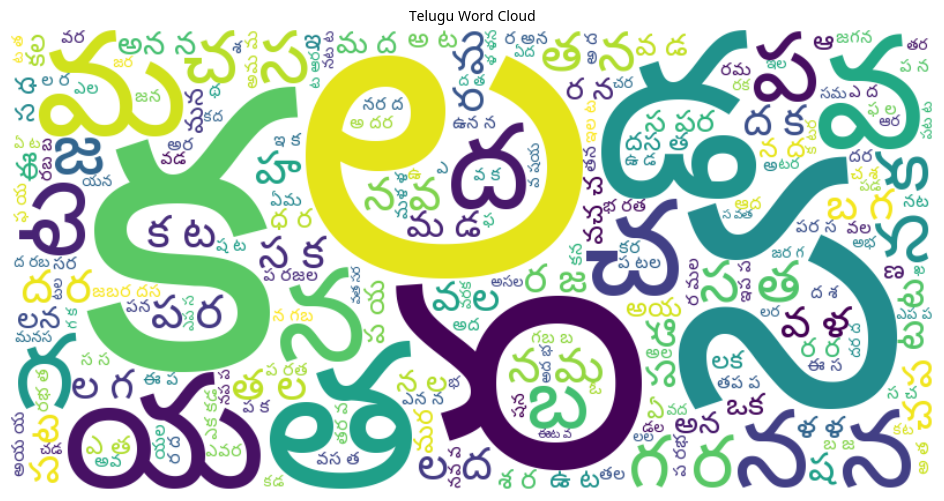

In [9]:
# Word Cloud Visualization
all_tokens = [token for tokens in df["tokens"] for token in tokens]
wordcloud = WordCloud(font_path=font_path, background_color="white", width=800, height=400).generate(" ".join(all_tokens))

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Telugu Word Cloud", fontproperties=telugu_font)
plt.show()

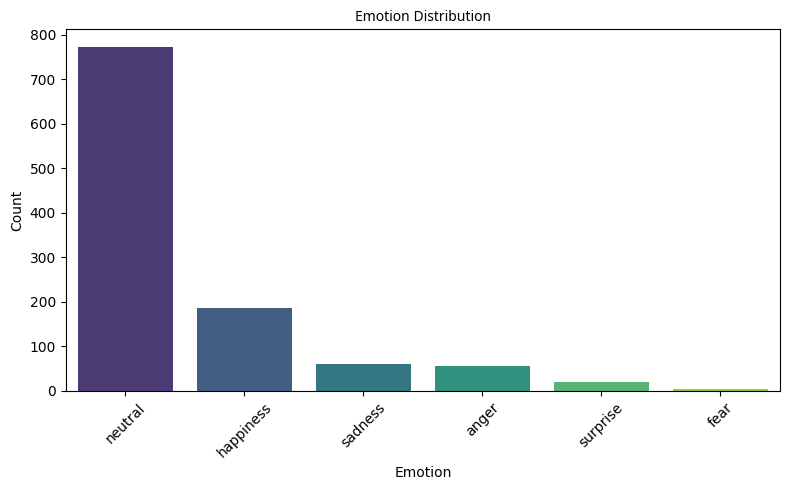

In [10]:
# Distribution of Emotions
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='emotion', order=df['emotion'].value_counts().index, palette="viridis")
plt.title("Emotion Distribution", fontproperties=telugu_font)
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
#TF-IDF Vectorization
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,3),          
    analyzer='char_wb',         
    sublinear_tf=True
)
X = vectorizer.fit_transform(df["clean_text"])
y = df["emotion"]


In [12]:
smote = SMOTE(random_state=42, k_neighbors=3)
X_res, y_res = smote.fit_resample(X, y)

In [13]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, stratify=y_res, random_state=42
)

In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
}

performance_summary = []


=== Training Logistic Regression ===
Accuracy: 0.9569
Precision: 0.9568
Recall: 0.9569
F1-score: 0.9563

Classification Report:
               precision    recall  f1-score   support

       anger       0.93      0.99      0.96       154
        fear       1.00      1.00      1.00       154
   happiness       0.97      0.90      0.93       155
     neutral       0.90      0.86      0.88       155
     sadness       0.96      1.00      0.98       155
    surprise       0.99      0.99      0.99       155

    accuracy                           0.96       928
   macro avg       0.96      0.96      0.96       928
weighted avg       0.96      0.96      0.96       928



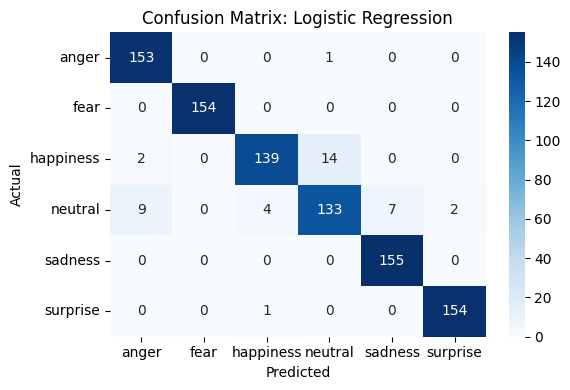


=== Training Naive Bayes ===
Accuracy: 0.8642
Precision: 0.8758
Recall: 0.8642
F1-score: 0.8453

Classification Report:
               precision    recall  f1-score   support

       anger       0.84      1.00      0.91       154
        fear       0.89      1.00      0.94       154
   happiness       0.92      0.86      0.89       155
     neutral       0.92      0.36      0.52       155
     sadness       0.75      0.97      0.85       155
    surprise       0.94      0.99      0.97       155

    accuracy                           0.86       928
   macro avg       0.88      0.86      0.85       928
weighted avg       0.88      0.86      0.85       928



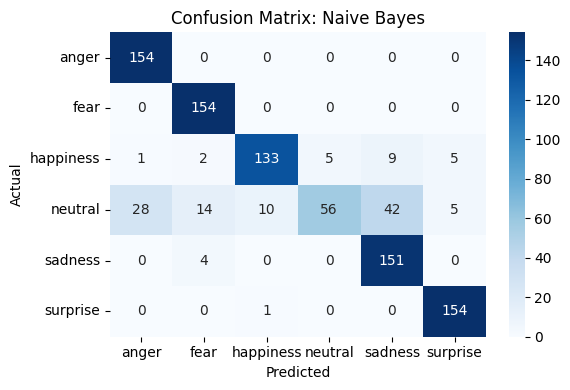


=== Training Linear SVM ===
Accuracy: 0.9806
Precision: 0.9807
Recall: 0.9806
F1-score: 0.9804

Classification Report:
               precision    recall  f1-score   support

       anger       0.96      1.00      0.98       154
        fear       1.00      1.00      1.00       154
   happiness       0.96      0.97      0.97       155
     neutral       0.97      0.91      0.94       155
     sadness       0.99      1.00      0.99       155
    surprise       1.00      1.00      1.00       155

    accuracy                           0.98       928
   macro avg       0.98      0.98      0.98       928
weighted avg       0.98      0.98      0.98       928



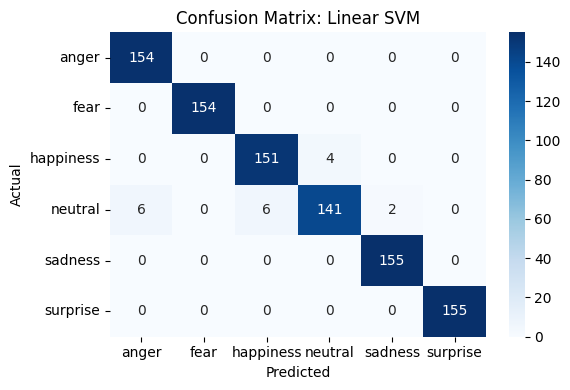


=== Training Random Forest ===
Accuracy: 0.9806
Precision: 0.9820
Recall: 0.9806
F1-score: 0.9808

Classification Report:
               precision    recall  f1-score   support

       anger       0.99      0.99      0.99       154
        fear       1.00      0.99      1.00       154
   happiness       1.00      0.94      0.97       155
     neutral       0.91      0.99      0.94       155
     sadness       1.00      0.99      0.99       155
    surprise       1.00      0.99      1.00       155

    accuracy                           0.98       928
   macro avg       0.98      0.98      0.98       928
weighted avg       0.98      0.98      0.98       928



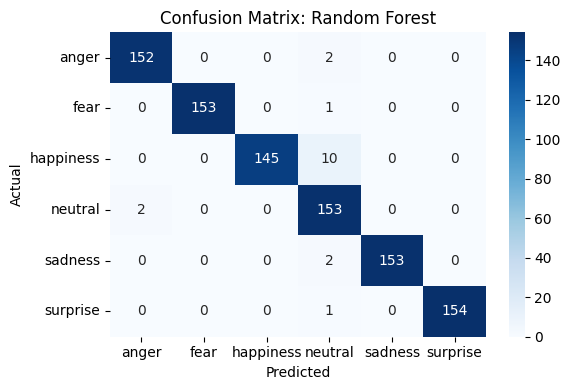

In [15]:
for name, model in models.items():
    print(f"\n=== Training {name} ===")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    performance_summary.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })
    
    labels = sorted(y_test.unique())
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.title(f"Confusion Matrix: {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


In [16]:
# Ensemble Model (Voting Classifier)
voting_model = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=2000, class_weight="balanced")),
        ('svm', LinearSVC(class_weight="balanced")),
        ('rf', RandomForestClassifier(n_estimators=200, random_state=42))
    ],
    voting='hard'
)

print("\n=== Training Ensemble (Voting Classifier) ===")
voting_model.fit(X_train, y_train)
y_pred = voting_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
print(f"Accuracy: {acc:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")


=== Training Ensemble (Voting Classifier) ===
Accuracy: 0.9806 | Precision: 0.9807 | Recall: 0.9806 | F1: 0.9805


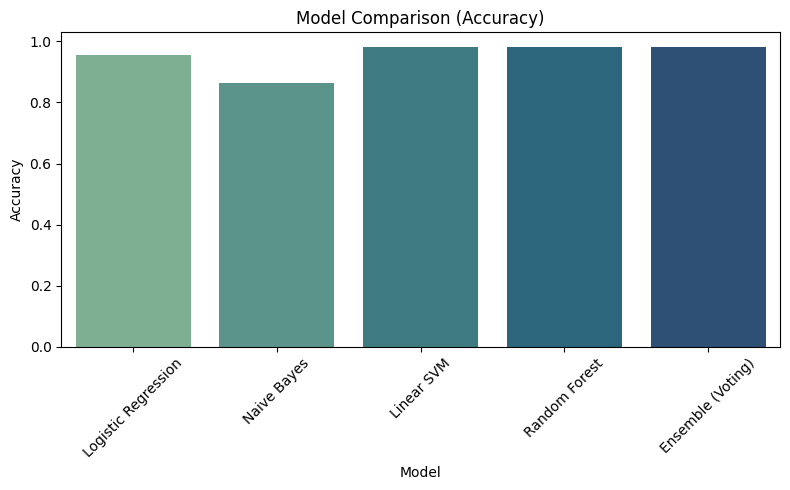


=== Final Performance Summary ===
                 Model  Accuracy  Precision    Recall  F1-Score
2           Linear SVM  0.980603   0.980658  0.980603  0.980383
4    Ensemble (Voting)  0.980603   0.980668  0.980603  0.980513
3        Random Forest  0.980603   0.982032  0.980603  0.980832
0  Logistic Regression  0.956897   0.956783  0.956897  0.956312
1          Naive Bayes  0.864224   0.875824  0.864224  0.845255


In [17]:
perf_df = pd.DataFrame(performance_summary)
perf_df.drop_duplicates(subset=['Model'], inplace=True)
perf_df.loc[len(perf_df)] = ["Ensemble (Voting)", acc, precision, recall, f1]

plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='Accuracy', data=perf_df, palette="crest")
plt.xticks(rotation=45)
plt.title("Model Comparison (Accuracy)")
plt.tight_layout()
plt.show()

print("\n=== Final Performance Summary ===")
print(perf_df.sort_values(by='Accuracy', ascending=False))

In [18]:
def predict_emotion(text, model, vectorizer):
    cleaned = " ".join(tokenize_and_clean_sample(text))
    X_new = vectorizer.transform([cleaned])
    pred = model.predict(X_new)
    return pred[0]

predict_emotion("సూపర్ మూవీ", voting_model, vectorizer)


'happiness'